<a href="https://colab.research.google.com/github/mochamadx5/MachineLearning_11_MochamadReza/blob/main/JS04/JS04_SOAL_KUIS1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [4]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [5]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Data Size
df.shape

(48842, 15)

In [9]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [27]:
# Jawab Soal 1
print("Inspeksi Profile Data :")
df.info()
print("Inspeksi Profile Data : ")
display(df.describe(include='all'))

# Mengganti karakter '?' menjadi nilai NaN bawaan Pandas
df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)

Inspeksi Profile Data :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
Inspeksi Profile Data : 


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,46043,4.884200e+04,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985,48842
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [28]:
# 2. Variabel apa yang memiliki nilai yang hilang dan berapa jumlahnya?
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [33]:
# Jawab Soal 2
# 1. Melakukan imputasi menggunakan modus (nilai terbanyak) pada kolom kategorikal
for col in missing_values.index:
    modus_kolom = df[col].mode()[0]
    df[col].fillna(modus_kolom, inplace=True)

# 2. Cek kembali apakah masih ada data yang hilang
print("Jumlah missing values setelah imputasi:")
print(df.isnull().sum())

Jumlah missing values setelah imputasi:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [38]:
# Jawab Soal 2
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
# Mengganti nilai kategori pekerjaan yang sangat sedikit/langka menjadi 'Others'

df['workclass'] = df['workclass'].replace(['Without-pay', 'Never-worked'], 'Others')
print("Pembersihan nilai kualitatif selesai.")
print(df['workclass'].value_counts())

Pembersihan nilai kualitatif selesai.
workclass
Private             36705
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Others                 31
Name: count, dtype: int64


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

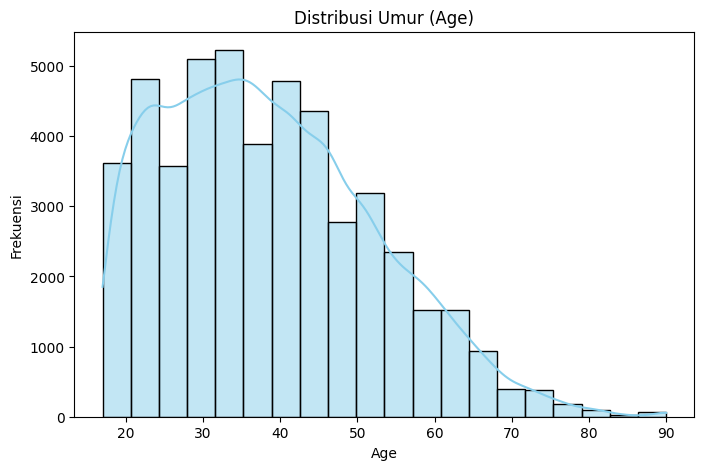

In [40]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribusi Umur (Age)')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

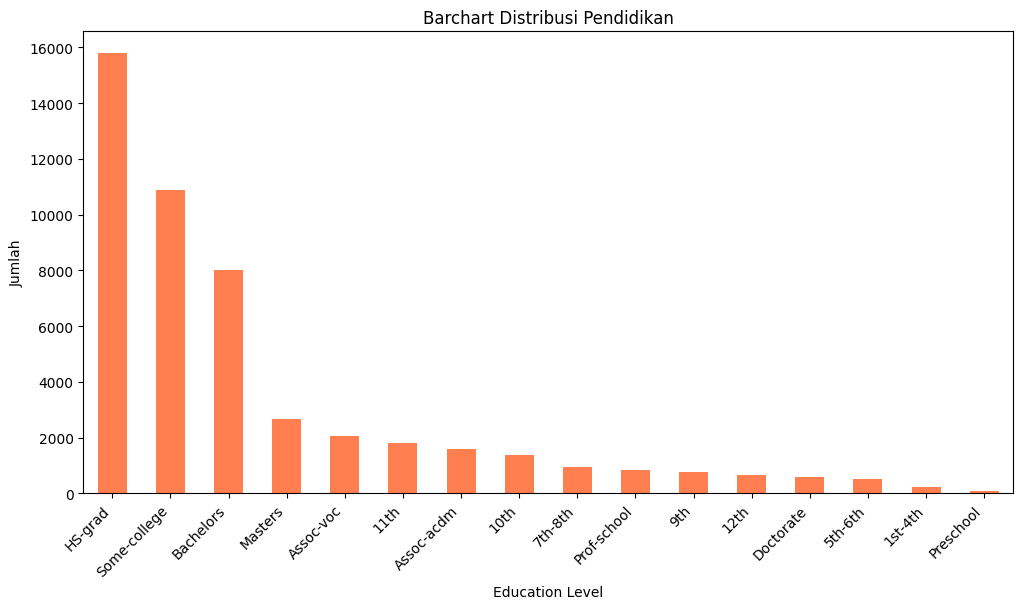

In [41]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 6))
df['education'].value_counts().plot(kind='bar', color='coral')
plt.title('Barchart Distribusi Pendidikan')
plt.xlabel('Education Level')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_1607/2294020924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='hours-per-week', data=df, palette='Set2')


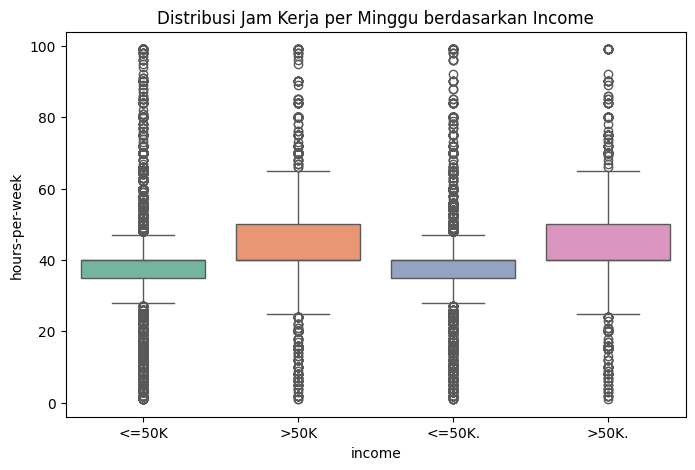

In [42]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='income', y='hours-per-week', data=df, palette='Set2')
plt.title('Distribusi Jam Kerja per Minggu berdasarkan Income')
plt.show()

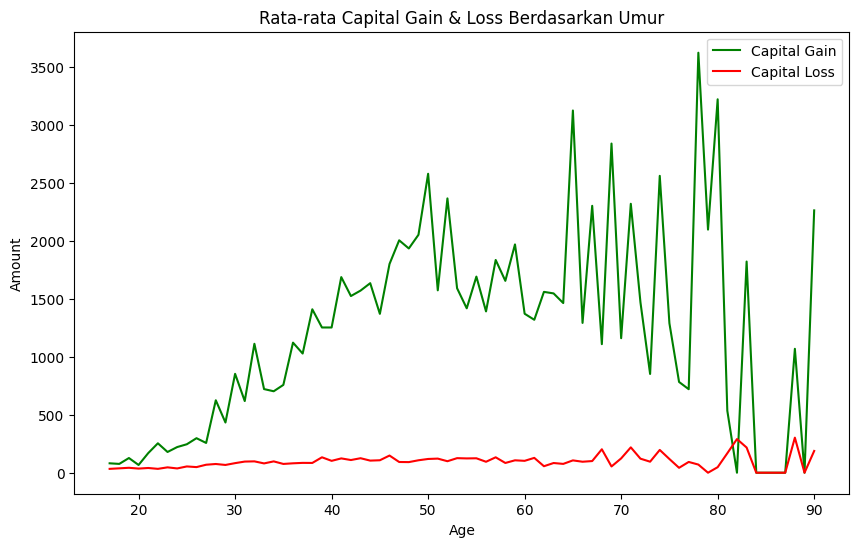

In [44]:
# Jawab 1.4 - Lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='capital-gain', data=df, label='Capital Gain', color='green', errorbar=None)
sns.lineplot(x='age', y='capital-loss', data=df, label='Capital Loss', color='red', errorbar=None)
plt.title('Rata-rata Capital Gain & Loss Berdasarkan Umur')
plt.xlabel('Age')
plt.ylabel('Amount')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [45]:
# Jawab dengan komentar python


'\n1. Fenomena pada distribusi \'age\': \nDistribusi umur terlihat condong ke kanan (right-skewed). Mayoritas data berada pada rentang usia produktif (20-40 tahun), kemudian perlahan menurun seiring bertambahnya usia.\n\n2. Strategi jika ada missing value pada \'age\':\nKarena \'age\' adalah tipe data numerik dengan distribusi yang *skewed* (tidak normal sempurna), imputasi menggunakan "Median" (nilai tengah) adalah strategi terbaik karena median lebih tahan terhadap nilai ekstrem/outlier dibandingkan rata-rata (Mean).\n\n3. Outlier pada \'income\' & \'hours-per-week\':\nDari grafik boxplot yang dibuat, terlihat banyak titik (outlier) baik di atas maupun di bawah *whiskers*. Kategori income \'<=50K\' memiliki outlier paling banyak terutama pada orang-orang yang bekerja dengan jam sangat rendah (part-time langka) atau sangat tinggi (overwork ekstrim).\n'

'''
1. Fenomena pada distribusi 'age':
Distribusi umur terlihat condong ke kanan (right-skewed). Mayoritas data berada pada rentang usia produktif (20-40 tahun), kemudian perlahan menurun seiring bertambahnya usia.

2. Strategi jika ada missing value pada 'age':
Karena age adalah tipe data numerik dengan distribusi yang skewed atau tidak normal sempurna, imputasi menggunakan Median adalah strategi terbaik karena median lebih tahan terhadap nilai ekstrem/outlier dibandingkan rata-rata.

3. Outlier pada 'income' & 'hours-per-week':
Dari grafik boxplot yang dibuat, terlihat banyak titik outlier baik di atas maupun di bawah whiskers. Kategori income '<=50K' memiliki outlier paling banyak terutama pada orang-orang yang bekerja dengan jam sangat rendah (part-time langka) atau sangat tinggi (overwork ekstrim).

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [53]:
# Jawab Soal 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Encoding 'sex' (Male/Female = 1/0)
df['sex'] = le.fit_transform(df['sex'])
# Encoding 'income' ('<=50K' -> 0, '>50K' -> 1)
df['income'] = le.fit_transform(df['income'])
# Cek hasil encoding
print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

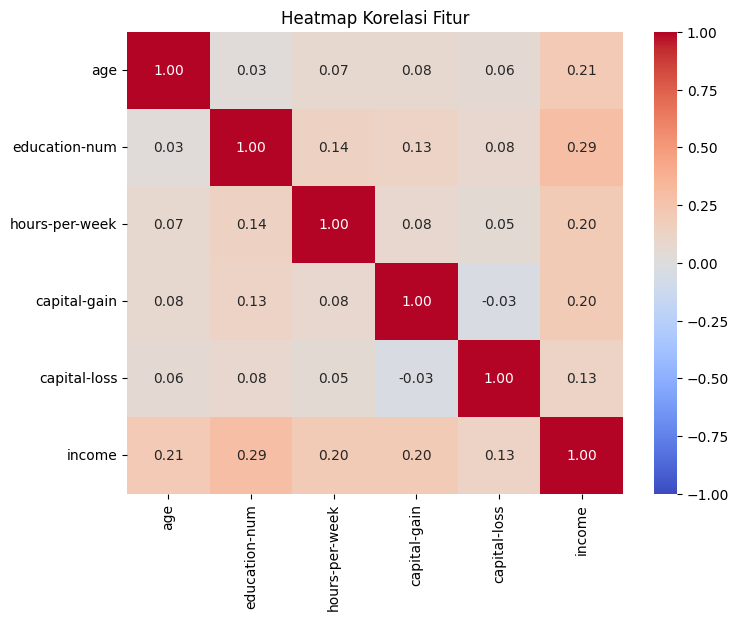

In [54]:
cols_to_corr = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur')
plt.show()


Berdasarkan hasil korelasi:
- Fitur 'education-num' (0.34) dan 'age' (0.23) memiliki korelasi positif moderat terhadap 'income'. Ini logis karena pendidikan yang lebih tinggi dan pengalaman kerja cenderung menaikkan kemungkinan mendapat pendapatan di atas $50K.
- 'hours-per-week' dan 'capital-gain' juga memiliki korelasi positif terhadap 'income', sejalan dengan bertambahnya pendapatan.
- Tidak ditemukan indikasi multikolinearitas (korelasi antar fitur independen yang mendekati 1) yang mengkhawatirkan.

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [58]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


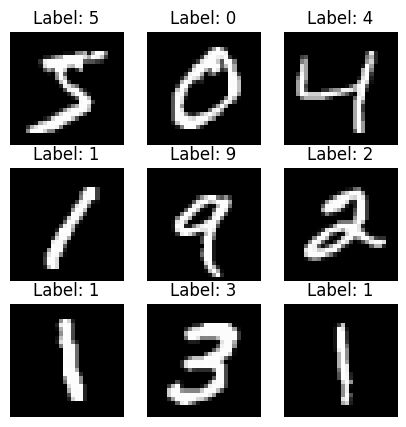

In [59]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

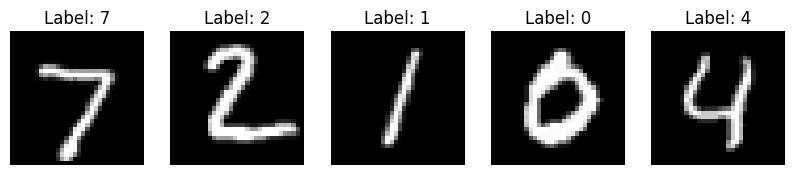

In [62]:
# Jawab Soal 1
import cv2
# Membuat array kosong ukuran (10000, 32, 32)
X_test_32 = np.zeros((X_test.shape[0], 32, 32))
# Loop upsampling seluruh data test
for i in range(X_test.shape[0]):
    # Resize dari 28x28 ke 32x32
    X_test_32[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)
# Tampilkan 5 data pertama hasil upsampling
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_32[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [63]:
# Jawab Soal 2
# Normalisasi rentang piksel citra 0-255 ke 0.0-1.0
X_test_norm = X_test_32 / 255.0

print(f"Nilai piksel maksimal setelah normalisasi: {X_test_norm.max()}")
print(f"Nilai piksel minimal setelah normalisasi: {X_test_norm.min()}")

Nilai piksel maksimal setelah normalisasi: 1.0
Nilai piksel minimal setelah normalisasi: 0.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [65]:
# Jawab Soal 3
# Menggunakan reshape, di mana dimensi kedua diset -1 agar array otomatis diratakan
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print("Shape asli citra:", X_test_norm.shape)
print("Shape citra setelah proses flatten:", X_test_flat.shape)

Shape asli citra: (10000, 32, 32)
Shape citra setelah proses flatten: (10000, 1024)
